# Silhouette Score

Silhouette Score is a **clustering evaluation metric** used to measure how well data points are assigned to their clusters.

It evaluates:

1. How similar a data point is to its own cluster.
2. How different a data point is from other clusters.

The Silhouette Score ranges from:

$$
-1 \leq Silhouette\ Score \leq 1
$$

### Interpretation

```text
Score close to +1
        ↓
Very good clustering

Score close to 0
        ↓
Overlapping clusters

Score close to -1
        ↓
Poor clustering / points may be assigned
to the wrong cluster


---

# 2. Formula

### Markdown Cell

```markdown
# Silhouette Score Formula

For a data point $i$:

$$
s(i) = \frac{b(i)-a(i)}
{\max(a(i),b(i))}
$$

Where:

### $a(i)$

Average distance between point $i$ and the other points in its **own cluster**.

### $b(i)$

The lowest average distance between point $i$ and points belonging to its **nearest neighboring cluster**.

Therefore:

$$
-1 \leq s(i) \leq 1
$$

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [10]:
df = sns.load_dataset("iris")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [11]:
df.shape

(150, 5)

In [12]:
df.shape

(150, 5)

In [13]:
features = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

X = df[features]

X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

In [15]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(
    X_scaled
)

labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [16]:
score = silhouette_score(
    X_scaled,
    labels
)

print("Silhouette Score:", score)

Silhouette Score: 0.45994823920518646


In [17]:
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

silhouette_scores

[0.5817500491982808,
 0.45994823920518646,
 0.38694104154427816,
 0.3459012795948778,
 0.3170794019356902,
 0.3201967939183684,
 0.3386917389489723,
 0.3423598384813203,
 0.35179267606402886]

In [18]:
silhouette_df = pd.DataFrame({
    "Number of Clusters": list(k_values),
    "Silhouette Score": silhouette_scores
})

silhouette_df

,Number of Clusters,Silhouette Score
0,2,0.581750
1,3,0.459948
2,4,0.386941
3,5,0.345901
4,6,0.317079
5,7,0.320197
6,8,0.338692
7,9,0.342360
8,10,0.351793


In [19]:
best_index = np.argmax(
    silhouette_scores
)

best_k = list(k_values)[best_index]

best_score = silhouette_scores[best_index]

print("Best K:", best_k)
print("Best Silhouette Score:", best_score)

Best K: 2
Best Silhouette Score: 0.5817500491982808


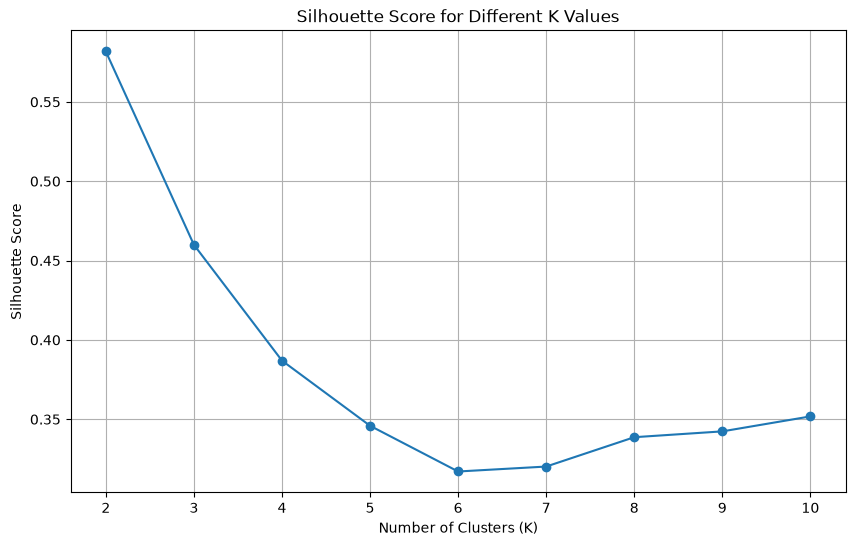

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.title(
    "Silhouette Score for Different K Values"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Silhouette Score"
)

plt.xticks(
    list(k_values)
)

plt.grid()

plt.show()

In [21]:
kmeans_best = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

best_labels = kmeans_best.fit_predict(
    X_scaled
)

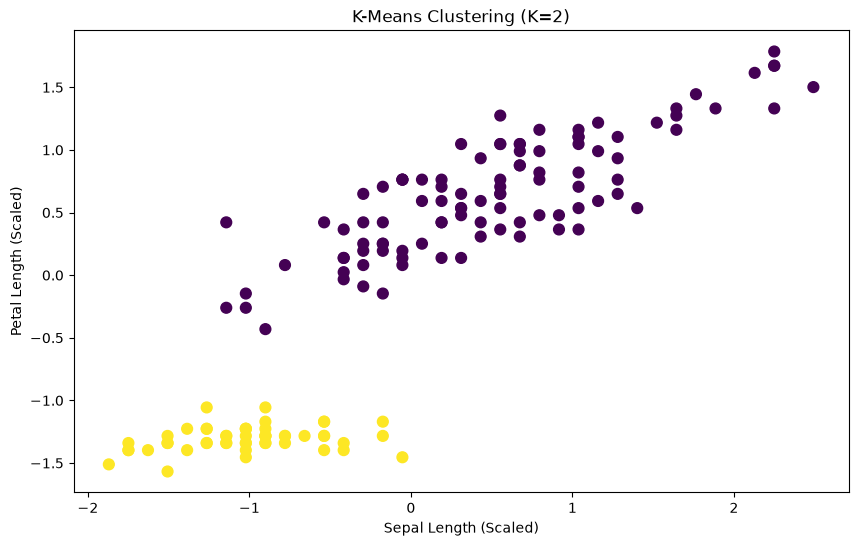

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 2],
    c=best_labels,
    s=60
)

plt.title(
    f"K-Means Clustering (K={best_k})"
)

plt.xlabel(
    "Sepal Length (Scaled)"
)

plt.ylabel(
    "Petal Length (Scaled)"
)

plt.show()